In [1]:
#Select Encoding for representation
import numpy as np
import pandas as pd
import os, re, math, platform
from pathlib import Path
import matplotlib.pyplot as plt
import json
import joblib
from scipy.stats import randint as sp_randint
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import RandomizedSearchCV
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import matthews_corrcoef, confusion_matrix
from sklearn.metrics import precision_recall_curve, roc_curve, auc, fbeta_score
from imblearn.metrics import geometric_mean_score
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier 
from xgboost import plot_importance
#!pip install lightgbm
from lightgbm import LGBMClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import GradientBoostingClassifier,RandomForestClassifier,ExtraTreesClassifier,AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from Bio import SeqIO
from Bio.SeqUtils.ProtParam import ProteinAnalysis as PA
from modlamp.descriptors import PeptideDescriptor, GlobalDescriptor
from matplotlib import pyplot
from sklearn.metrics import matthews_corrcoef, confusion_matrix,precision_recall_curve, roc_curve, auc, fbeta_score,roc_auc_score
from fea_extract import read_fasta,insert_AAC,insert_DPC,insert_CKSAAGP,insert_CTD,insert_PAAC,insert_AAI,insert_GTPC,insert_QSO,insert_AAE,insert_PSAAC,insert_word2int,insert_ASDC
import warnings 
from tools import cv,evaluate
warnings.filterwarnings('ignore')

In [2]:
seed = 10
Path('./results/evalue/').mkdir(exist_ok=True,parents=True)
Path('./results/evalue_balance/').mkdir(exist_ok=True,parents=True)

In [3]:
def pro_data(seq):
    df_n = insert_PAAC(seq)
    df_n = insert_AAC(df_n)
    df_n = insert_CKSAAGP(df_n)
    df_n = insert_CTD(df_n)
    #df_n = insert_DPC(df_n)
    #df_n = insert_GTPC(df_n)
    #df_n = insert_QSO(df_n)
    #df_n = insert_AAE(df_n)
    #df_n = insert_ASDC(df_n)
    #df_n = insert_word2int(df_n)
    return df_n

In [4]:
seq_X_train = pd.read_csv('data/train/X_train.csv')
seq_X_test = pd.read_csv('data/test/X_test.csv')
seq_y_train = pd.read_csv('data/train/y_train.csv')
seq_y_test = pd.read_csv('data/test/y_test.csv')

In [5]:
Seq_X_train = pro_data(seq_X_train)
Seq_X_test = pro_data(seq_X_test)

In [6]:
Seq_X_train.to_csv('data/train/Seq_X_train_all.csv',index=False)
Seq_X_test.to_csv('data/test/Seq_X_test_all.csv',index=False)

In [7]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import VotingClassifier
from mlxtend.classifier import StackingClassifier

from sklearn.svm import LinearSVC

ml = ["DT","LGBM","GBDT","ET","SVM","MLP","RF","XGBoost","LR","AB","voting_clf","stacking","Two_eclf"]

layer_one= [  LGBMClassifier(random_state = seed),ExtraTreesClassifier(random_state=seed),RandomForestClassifier(random_state=seed),MLPClassifier(hidden_layer_sizes=900,learning_rate="adaptive",random_state=seed)]
                     #('rf5',GaussianNB()),
#                   ('SVM', SVC(kernel='linear',probability=True))]
layer_two = [SVC(random_state=seed,probability=True), ExtraTreesClassifier(random_state=seed),RandomForestClassifier(random_state=seed),LGBMClassifier(random_state = seed)]
             #GaussianNB()]
#                   ('SVC', SVC(kernel='linear',probability=True))]



layer_two_meta= StackingClassifier(classifiers = layer_two, meta_classifier=LogisticRegression())    
DT  = DecisionTreeClassifier(random_state=seed)
LGBM = LGBMClassifier(random_state = seed)
GBDT = GradientBoostingClassifier(random_state=seed)
ET = ExtraTreesClassifier(random_state=seed)
SVM = SVC(random_state=seed,probability=True)
MLP = MLPClassifier(hidden_layer_sizes=1200,learning_rate="adaptive",random_state=seed)
RF = RandomForestClassifier(random_state=seed)
XGBoost = XGBClassifier(random_state=seed)
LR  = LogisticRegression(random_state=seed,solver='liblinear')
AB = AdaBoostClassifier(random_state=seed)


#SDG = SGDClassifier(max_iter=1200, tol=1e-3) 
voting_clf = VotingClassifier(estimators = [('lgbm',LGBM),('rf',RF),('xgb',XGBoost),('ET',ET),('GBDT',GBDT)], voting = 'soft')
Bagging_clf = BaggingClassifier(base_estimator=RandomForestClassifier(random_state=seed))
#VOT_STACK = StackingClassifier(classifiers = voting_clf, meta_classifier=LR)
stacking = StackingClassifier(classifiers=[LGBM,XGBoost,GBDT],meta_classifier=LR)
Two_eclf = StackingClassifier(classifiers=layer_one, meta_classifier=layer_two_meta)

In [8]:

"""
import optuna
from sklearn.model_selection import cross_val_score

# Define the objective function for Optuna optimization
def objective(trial):
    # Define the hyperparameters to optimize for each model
    params = {}
    if model_name == "DT":
        params = {
            "max_depth": trial.suggest_int("max_depth", 1, 32),
            "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
            # Add more DecisionTreeClassifier hyperparameters to optimize
        }
    elif model_name == "LGBM":
        params = {
            "num_leaves": trial.suggest_int("num_leaves", 2, 256),
            "learning_rate": trial.suggest_loguniform("learning_rate", 0.01, 0.1),
            # Add more LightGBM hyperparameters to optimize
        }
    # Add elif blocks for other models

    # Create the model with the hyperparameters
    model = eval(model_name)(**params)
    
    # Evaluate the model using cross-validation
    score = cross_val_score(model, X_train, y_train, cv=5, scoring="accuracy").mean()
    
    return score

# Create a study for Optuna optimization
study = optuna.create_study(direction="maximize")

# Perform optimization for each model
for model_name in ml:
    print('Optimizing {}'.format(model_name))
    study.optimize(objective, n_trials=100)  # Adjust the number of trials as needed

# Get the best hyperparameters and their scores for each model
best_params = {}
for model_name in ml:
    best_params[model_name] = study.best_params

# Print the best hyperparameters for each model
for model_name, params in best_params.items():
    print(f"Best hyperparameters for {model_name}: {params}")
    
    """

'\nimport optuna\nfrom sklearn.model_selection import cross_val_score\n\n# Define the objective function for Optuna optimization\ndef objective(trial):\n    # Define the hyperparameters to optimize for each model\n    params = {}\n    if model_name == "DT":\n        params = {\n            "max_depth": trial.suggest_int("max_depth", 1, 32),\n            "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),\n            # Add more DecisionTreeClassifier hyperparameters to optimize\n        }\n    elif model_name == "LGBM":\n        params = {\n            "num_leaves": trial.suggest_int("num_leaves", 2, 256),\n            "learning_rate": trial.suggest_loguniform("learning_rate", 0.01, 0.1),\n            # Add more LightGBM hyperparameters to optimize\n        }\n    # Add elif blocks for other models\n\n    # Create the model with the hyperparameters\n    model = eval(model_name)(**params)\n    \n    # Evaluate the model using cross-validation\n    score = cross_val_score

In [9]:
fea = Seq_X_train.columns[2:]
X_train = Seq_X_train[fea].to_numpy()
X_test = Seq_X_test[fea].to_numpy()
y_train = seq_y_train.to_numpy()
y_test = seq_y_test.to_numpy()

In [10]:
index = []
ALL_eval=pd.DataFrame()
for i in ml:
    print('process_{}'.format(i))
    model = eval(i)
    Evals = cv(model,X_train,y_train)
    ALL_eval = pd.concat([ALL_eval,Evals],axis=1)
    index.append("{}".format(i))
ALL_eval.columns = index

process_DT
process_LGBM
[LightGBM] [Info] Number of positive: 608, number of negative: 608
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.017988 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 44550
[LightGBM] [Info] Number of data points in the train set: 1216, number of used features: 265
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Number of positive: 625, number of negative: 591
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.012528 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 43974
[LightGBM] [Info] Number of data points in the train set: 1216, number of used features: 265
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.513980 -> initscore=0.055936
[LightGBM] [Info] Start

In [11]:
#5-fold cross validation for the main dataset
#performance improvement from MCC 0.51 (AntiCP 2.0) to 0.54
#AUROC >> 0.83 >> 0.860
ALL_eval

,DT,LGBM,GBDT,ET,SVM,MLP,RF,XGBoost,LR,AB,voting_clf,stacking,Two_eclf
ACC,0.855263,0.922368,0.911842,0.918421,0.903947,0.921711,0.911842,0.915132,0.897368,0.881579,0.923026,0.917763,0.925658
F1,0.857621,0.920290,0.910178,0.914762,0.902318,0.920908,0.909453,0.913646,0.895373,0.880566,0.921159,0.916044,0.923627
F2,0.867709,0.908146,0.903150,0.894414,0.893257,0.918981,0.897369,0.906928,0.887775,0.879333,0.910082,0.907188,0.910277
GMean,0.854604,0.922373,0.912015,0.917812,0.904157,0.921029,0.911774,0.915133,0.897175,0.881618,0.923215,0.917934,0.925757
SEN,0.874762,0.900377,0.898658,0.881421,0.887390,0.917872,0.889607,0.902649,0.883017,0.878554,0.903008,0.901534,0.901647
PREC,0.842020,0.941953,0.922707,0.951205,0.918148,0.924834,0.930879,0.925694,0.909396,0.882794,0.940970,0.931874,0.947034
SPEC,0.835470,0.945290,0.925856,0.955925,0.921349,0.924777,0.934768,0.928156,0.912250,0.884747,0.944261,0.934989,0.950616
MCC,0.711261,0.846054,0.824287,0.839126,0.808420,0.843735,0.824723,0.830860,0.795764,0.762858,0.847347,0.836456,0.852389
AUC,0.855116,0.973772,0.969656,0.973862,0.961719,0.968661,0.970234,0.973966,0.953345,0.945085,0.976132,0.938567,0.938424
AUPR,0.799342,0.977354,0.973305,0.977559,0.964984,0.971770,0.973476,0.977327,0.957911,0.950254,0.979597,0.923196,0.922541


In [12]:
index = []
ALL_eval_test=pd.DataFrame()
for i in ml:
    eval_dict = []
    print('process_{}'.format(i))
    model = eval(i)
    model.fit(X_train,y_train)
    eval_dictionary = evaluate(X_test,y_test,model)
    eval_dict = eval_dict+[eval_dictionary]
    Evals = pd.DataFrame(eval_dict).T
    ALL_eval_test = pd.concat([ALL_eval_test,Evals],axis=1)
    index.append("{}".format(i))
ALL_eval_test.columns = index

process_DT
process_LGBM
[LightGBM] [Info] Number of positive: 763, number of negative: 757
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.016758 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 46855
[LightGBM] [Info] Number of data points in the train set: 1520, number of used features: 265
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.501974 -> initscore=0.007895
[LightGBM] [Info] Start training from score 0.007895
process_GBDT
process_ET
process_SVM
process_MLP
process_RF
process_XGBoost
process_LR
process_AB
process_voting_clf
[LightGBM] [Info] Number of positive: 763, number of negative: 757
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.012099 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 46855
[LightGBM] [Info] Number of data points in the train set: 1520, number of used features: 265
[LightGB

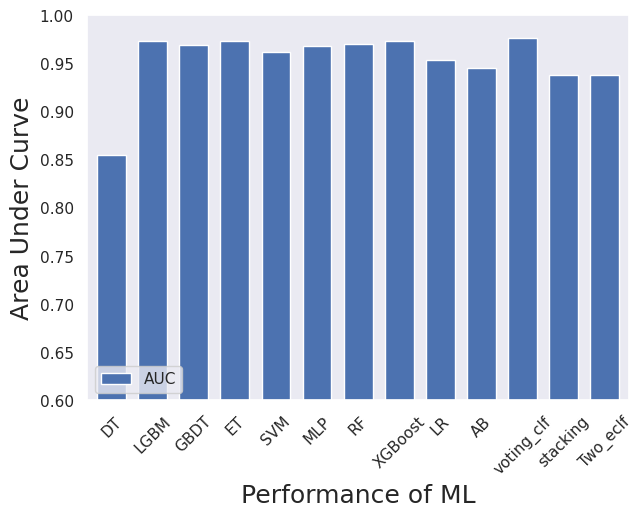

In [13]:
import seaborn as sns
evals = ALL_eval.loc[['AUC'],:]
sns.set()
evals.T.plot.bar(figsize=(7,5),rot=45,width = 0.7,grid = False)
plt.ylim(0.6,1.0)
plt.ylabel('Area Under Curve',fontsize=18)
plt.xlabel('Performance of ML',fontsize=18)
plt.legend(loc =  'lower left' )

In [14]:
ALL_eval_test

,DT,LGBM,GBDT,ET,SVM,MLP,RF,XGBoost,LR,AB,voting_clf,stacking,Two_eclf
ACC,0.829396,0.905512,0.892388,0.895013,0.892388,0.918635,0.905512,0.905512,0.895013,0.889764,0.908136,0.905512,0.910761
F1,0.829396,0.904255,0.893506,0.890110,0.890667,0.918206,0.903743,0.905759,0.891304,0.891192,0.907652,0.905263,0.909574
F2,0.828092,0.895680,0.897704,0.864461,0.880802,0.913866,0.892291,0.905759,0.871413,0.896767,0.903361,0.902413,0.900948
GMean,0.829399,0.905420,0.892330,0.893903,0.892253,0.918623,0.905329,0.905511,0.894366,0.889670,0.908124,0.905511,0.910670
SEN,0.827225,0.890052,0.900524,0.848168,0.874346,0.910995,0.884817,0.905759,0.858639,0.900524,0.900524,0.900524,0.895288
PREC,0.831579,0.918919,0.886598,0.936416,0.907609,0.925532,0.923497,0.905759,0.926554,0.882051,0.914894,0.910053,0.924324
SPEC,0.831579,0.921053,0.884211,0.942105,0.910526,0.926316,0.926316,0.905263,0.931579,0.878947,0.915789,0.910526,0.926316
MCC,0.658804,0.811440,0.784864,0.793626,0.785326,0.837380,0.811759,0.811022,0.792207,0.779686,0.816381,0.811072,0.821944
AUC,0.829402,0.973023,0.957922,0.963516,0.960623,0.969716,0.962441,0.968063,0.958969,0.946652,0.966520,0.919138,0.922761
AUPR,0.774517,0.976278,0.962569,0.968655,0.964323,0.973823,0.967314,0.972585,0.961219,0.944650,0.972003,0.894413,0.900365


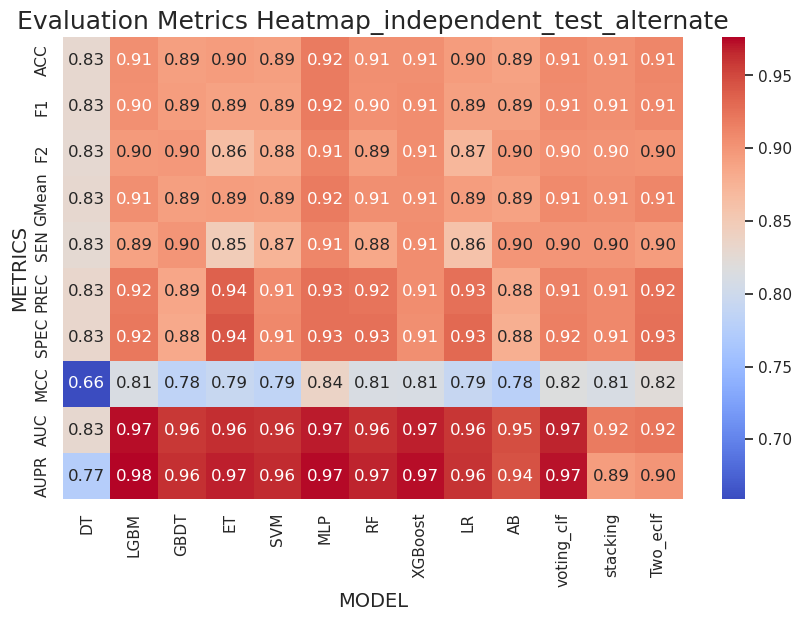

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming ALL_eval_test is a DataFrame with metrics as columns and models as rows

# Create a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(ALL_eval_test, cmap='coolwarm', annot=True, fmt=".2f", cbar=True)

plt.title('Evaluation Metrics Heatmap_independent_test_alternate', fontsize=18)
plt.xlabel('MODEL', fontsize=14)
plt.ylabel('METRICS',size=14)

plt.show()

process_DT
process_LGBM
[LightGBM] [Info] Number of positive: 763, number of negative: 757
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010997 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 46855
[LightGBM] [Info] Number of data points in the train set: 1520, number of used features: 265
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.501974 -> initscore=0.007895
[LightGBM] [Info] Start training from score 0.007895


ExplainerError: Additivity check failed in TreeExplainer! Please ensure the data matrix you passed to the explainer is the same shape that the model was trained on. If your data shape is correct then please report this on GitHub. This check failed because for one of the samples the sum of the SHAP values was -5.376999, while the model output was -5.898155. If this difference is acceptable you can set check_additivity=False to disable this check.

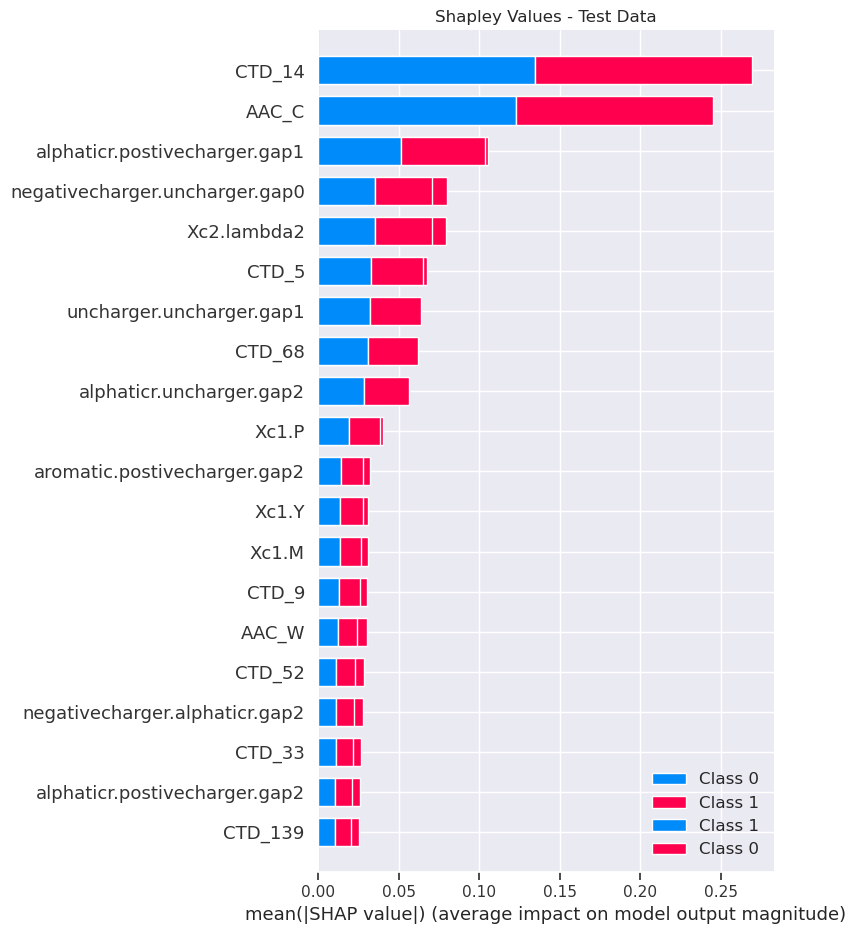

In [16]:
"""
import shap
index = []
ALL_eval_test=pd.DataFrame()
for i in ml:
    eval_dict = []
    print('process_{}'.format(i))
    model = eval(i)
    model.fit(X_train,y_train)
    eval_dictionary = evaluate(X_test,y_test,model)
    explainer_train = shap.Explainer(model,X_train)
    explainer_test = shap.Explainer(model,X_test)
    # Calculate Shapley Values for Training Data
    shap_values_train = explainer_train.shap_values(X_train)

# Calculate Shapley Values for Test Data
    shap_values_test = explainer_test.shap_values(X_test)

# Visualize Shapley Values for Training Data
    shap.summary_plot(shap_values_train, X_train, feature_names=fea, show=False)
    plt.title('Shapley Values - Training Data')
    plt.savefig('shapley_train.png')

# Visualize Shapley Values for Test Data
    shap.summary_plot(shap_values_test, X_test, feature_names=fea, show=False)
    plt.title('Shapley Values - Test Data')
    plt.savefig('shapley_test.png')
    eval_dict = eval_dict+[eval_dictionary]
    Evals = pd.DataFrame(eval_dict).T
    ALL_eval_test = pd.concat([ALL_eval_test,Evals],axis=1)
    index.append("{}".format(i))
ALL_eval_test.columns = index

"""